# 06 LLM Intervention
**Project:** Quantifying Politeness in Online Educational Forums  
**Author:** Karan Raman  
**Purpose:** Explore the feasibility of using a free local LLM to rewrite
impolite or neutral forum posts into more polite versions.

**Evaluation dimensions:**
1. Politeness gain, does the rewritten post score higher with ConvoKit?
2. Semantic preservation, does the rewrite keep the original meaning?
3. Qualitative inspection, does it read naturally?

**Run After:** 05_causal_analysis.ipynb
**Input:** data/processed/posts_analysis.parquet
**Output:** data/outputs/llm_top_improved.csv

## 0. Install & imports

In [1]:
import subprocess
subprocess.run(['pip', 'install', 'sentence-transformers', '-q'], check=True)
print('sentence-transformers installed.')

sentence-transformers installed.


In [2]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import time
from pathlib import Path
from convokit import PolitenessStrategies
from transformers import pipeline
import spacy

sns.set_theme(style='whitegrid', font_scale=1.1)
mpl.rcParams.update({
    'figure.figsize'    : (10, 6),
    'figure.dpi'        : 120,
    'savefig.dpi'       : 300,
    'savefig.bbox'      : 'tight',
    'savefig.facecolor' : 'white',
    'font.size'         : 11,
    'axes.titlesize'    : 13,
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'grid.alpha'        : 0.3,
})

BLUE, RED, GREEN, GREY = '#2166AC', '#D6604D', '#1A9641', '#878787'
sns.set_palette([BLUE, RED, GREEN, GREY, '#F4A582'])

DATA_PROCESSED = Path('../data/processed')
DATA_OUT       = Path('../data/outputs')
DATA_OUT.mkdir(parents=True, exist_ok=True)

N_SAMPLES   = 100
RANDOM_SEED = 42

nlp = spacy.load('en_core_web_sm')
ps  = PolitenessStrategies()

print('Setup complete.')

Setup complete.


## 1. Load rewriting model
Loading the T5-based paraphrasing model used to rewrite impolite posts into more polite versions.

In [3]:
# load T5 paraphrasing model
from transformers import T5ForConditionalGeneration, T5Tokenizer
import torch

model_name = 'humarin/chatgpt_paraphraser_on_T5_base'
tokenizer  = T5Tokenizer.from_pretrained(model_name)
model      = T5ForConditionalGeneration.from_pretrained(model_name)
model.eval()

def rewrite_post(text):
    prompt = f"make this more polite and respectful: {str(text)[:400]}"
    inputs = tokenizer(prompt, return_tensors='pt',
                       max_length=256, truncation=True, padding=True)
    with torch.no_grad():
        outputs = model.generate(**inputs, num_beams=4,
                                 max_length=256, early_stopping=True)
    return tokenizer.decode(outputs[0], skip_special_tokens=True).strip()

print(f'Test: {rewrite_post("Give me the answer now.")}')

Loading weights:   0%|          | 0/257 [00:00<?, ?it/s]

Test: Now, let's make this more polite and respectful: What's the answer?


## 2. Load and sample impolite/neutral posts

In [4]:
# load data and sample impolite/neutral posts for rewriting

df = pd.read_parquet(DATA_PROCESSED / 'posts_scored.parquet')
df['politeness_score'] = pd.to_numeric(df['politeness_score'], errors='coerce')

candidates = df[df['politeness_score'] <= 0].copy()
sample     = candidates.sample(n=N_SAMPLES, random_state=RANDOM_SEED).reset_index(drop=True)

print(f'Candidates : {len(candidates):,}')
print(f'Sample size: {len(sample)}')
print(sample['politeness_score'].value_counts().sort_index().to_string())

Candidates : 11,717
Sample size: 100
politeness_score
-3     1
-2     9
-1    27
 0    63


## 3. Rewrite posts with HuggingFace T5

In [5]:
# rewrite all sampled posts
rewritten_texts = []
for i, row in sample.iterrows():
    rewritten_texts.append(rewrite_post(row['text_clean']))
    if (i + 1) % 10 == 0:
        print(f'  {i+1}/{len(sample)} done')

sample['text_rewritten'] = rewritten_texts
print(f'Successfully rewritten: {sample["text_rewritten"].notna().sum()}/{len(sample)}')

  10/100 done
  20/100 done
  30/100 done
  40/100 done
  50/100 done
  60/100 done
  70/100 done
  80/100 done
  90/100 done
  100/100 done
Successfully rewritten: 100/100


In [6]:
pd.set_option('display.max_colwidth', 200)
sample[['text_clean', 'text_rewritten', 'politeness_score']].head(5)

,text_clean,text_rewritten,politeness_score
0,Staff should address this technical glitch.,It's time for staff to make this technically incorrect and make this more polite and respectful: staff should address this issue.,0
1,"Your essay will receive the middle score from your 3 peer reviewers. The lowest score will not be counted. Thus, if you received an unfair peer review (such as getting all zeros), this will not be...","Your essay will receive the middle score from your 3 peer reviewers. The lowest score will not be counted. Therefore, if you received an unfair peer review (such as getting all zeros), this will n...",-2
2,I agree. In the video it was stated that his body temperature started to level out the longer he exercised and she didn't believe he would have gotten much colder. So if you kept moving I think it...,I think it's just my observation. The video showed that his body temperature started to drop as he continued to exercise and she didn't think he would have gotten much colder. So if you continued ...,0
3,"Parents who say, \I can't get this 'new' math.\"" Well, put yourself to work and problem solve what you need...and you will get the math! That is a better message...\""it doesn't come easily in our ...","To parents who think they can't grasp the new math, it's important to be polite and respectful. Put in the extra effort and solve the problem, and you'll see that math won't be a luxury in our fam...",0
4,Could you be more specific? What exactly is it that you think was left out? Some journal articles don't have methodology sections.,"Would you be able to elaborate on this in detail? What do you believe was not included, and why are certain journal articles missing the methodology section?",0


## 4. Re-score rewritten posts with ConvoKit

In [7]:
# feature lists needed for scoring
positive = [
    'feature_politeness_==Please==',
    'feature_politeness_==Please_start==',
    'feature_politeness_==Hedges==',
    'feature_politeness_==HASHEDGE==',
    'feature_politeness_==Gratitude==',
    'feature_politeness_==Deference==',
    'feature_politeness_==Apologizing==',
    'feature_politeness_==1st_person_pl.==',
    'feature_politeness_==Indirect_(btw)==',
    'feature_politeness_==Indirect_(greeting)==',
    'feature_politeness_==HASPOSITIVE==',
]

negative = [
    'feature_politeness_==Direct_question==',
    'feature_politeness_==Direct_start==',
    'feature_politeness_==2nd_person==',
    'feature_politeness_==2nd_person_start==',
    'feature_politeness_==HASNEGATIVE==',
]

# score original and rewritten posts with ConvoKit
def score_convokit(text):
    try:
        strategies = ps.transform_utterance(str(text), spacy_nlp=nlp).meta['politeness_strategies']
        pos = sum(strategies.get(k, 0) for k in positive)
        neg = sum(strategies.get(k, 0) for k in negative)
        return pos - neg
    except:
        return np.nan

rewritten_valid = sample.dropna(subset=['text_rewritten']).copy()
rewritten_valid['politeness_original']  = rewritten_valid['text_clean'].apply(score_convokit)
rewritten_valid['politeness_rewritten'] = rewritten_valid['text_rewritten'].apply(score_convokit)
rewritten_valid['improvement']          = rewritten_valid['politeness_rewritten'] - rewritten_valid['politeness_original']

print(f'Mean original score  : {rewritten_valid["politeness_original"].mean():.3f}')
print(f'Mean rewritten score : {rewritten_valid["politeness_rewritten"].mean():.3f}')
print(f'Mean improvement     : {rewritten_valid["improvement"].mean():.3f}')

Mean original score  : -0.480
Mean rewritten score : -0.020
Mean improvement     : 0.460


## 5. Semantic preservation cosine similarity
Checks whether the rewrite kept the original meaning.

In [8]:
import logging
import warnings
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer

logging.getLogger('sentence_transformers').setLevel(logging.ERROR)
logging.getLogger('transformers').setLevel(logging.ERROR)
logging.disable(logging.WARNING)
warnings.filterwarnings('ignore')

st_model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

orig_emb = st_model.encode(rewritten_valid['text_clean'].tolist(), batch_size=32, convert_to_numpy=True)
rew_emb  = st_model.encode(rewritten_valid['text_rewritten'].tolist(), batch_size=32, convert_to_numpy=True)

similarities = [cosine_similarity([o], [r])[0][0] for o, r in zip(orig_emb, rew_emb)]
rewritten_valid['semantic_similarity'] = similarities

print(f'Mean similarity    : {np.mean(similarities):.3f}')
print(f'Posts with sim>0.8 : {(np.array(similarities) > 0.8).sum()}/{len(similarities)}')
print(f'Posts with sim>0.9 : {(np.array(similarities) > 0.9).sum()}/{len(similarities)}')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Mean similarity    : 0.815
Posts with sim>0.8 : 64/100
Posts with sim>0.9 : 23/100


## 6. Visualise results

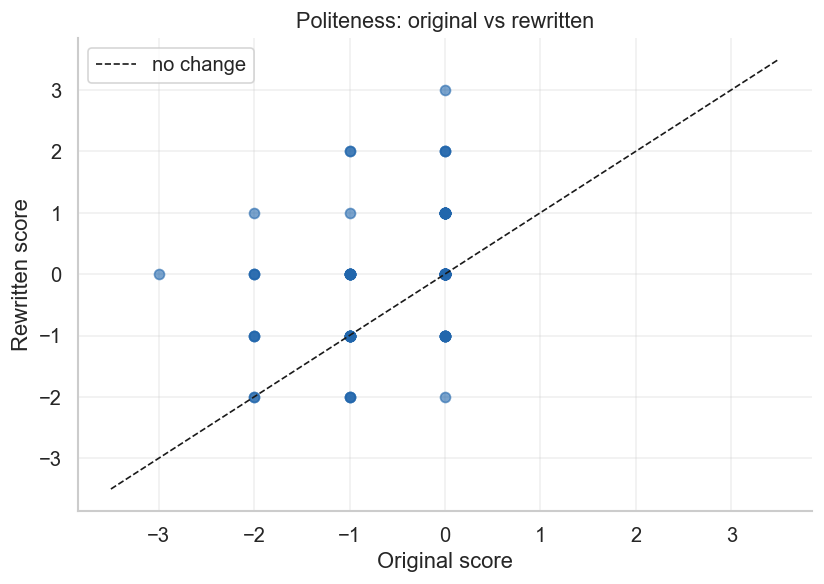

In [9]:
# scatter plot: original vs rewritten politeness scores
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(rewritten_valid['politeness_original'],
           rewritten_valid['politeness_rewritten'],
           alpha=0.6, color=BLUE)
lim = max(abs(rewritten_valid['politeness_original'].min()),
          abs(rewritten_valid['politeness_rewritten'].max())) + 0.5
ax.plot([-lim, lim], [-lim, lim], 'k--', linewidth=1, label='no change')
ax.set_xlabel('Original score')
ax.set_ylabel('Rewritten score')
ax.set_title('Politeness: original vs rewritten')
ax.legend()
plt.tight_layout()
plt.savefig(DATA_OUT / 'fig_llm_scatter.png')
plt.show()

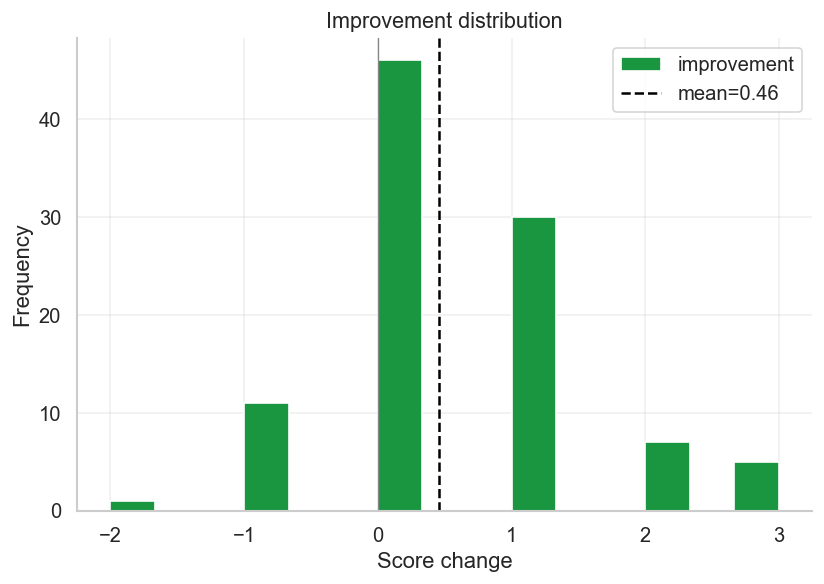

In [10]:
# improvement distribution
fig, ax = plt.subplots(figsize=(7, 5))
rewritten_valid['improvement'].plot(kind='hist', bins=15, ax=ax, color=GREEN, edgecolor='white')
ax.axvline(rewritten_valid['improvement'].mean(), color='black', linestyle='--',
           label=f"mean={rewritten_valid['improvement'].mean():.2f}")
ax.axvline(0, color=GREY, linestyle='-', linewidth=0.8)
ax.set_title('Improvement distribution')
ax.set_xlabel('Score change')
ax.legend()
plt.tight_layout()
plt.savefig(DATA_OUT / 'fig_llm_improvement.png')
plt.show()

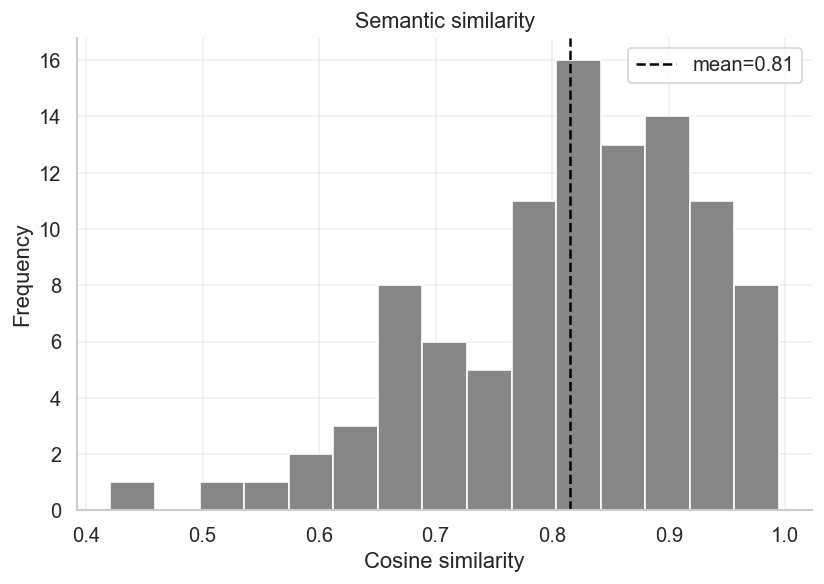

In [11]:
# semantic similarity distribution
fig, ax = plt.subplots(figsize=(7, 5))
pd.Series(similarities).plot(kind='hist', bins=15, ax=ax, color=GREY, edgecolor='white')
ax.axvline(np.mean(similarities), color='black', linestyle='--',
           label=f'mean={np.mean(similarities):.2f}')
ax.set_title('Semantic similarity')
ax.set_xlabel('Cosine similarity')
ax.legend()
plt.tight_layout()
plt.savefig(DATA_OUT / 'fig_llm_similarity.png')
plt.show()

## 7. Qualitative inspection
Read the best and worst rewrites to judge naturalness.

In [12]:
pd.set_option('display.max_colwidth', 200)
cols = ['text_clean', 'text_rewritten', 'politeness_original',
        'politeness_rewritten', 'improvement', 'semantic_similarity']

print('Top 5 most improved:')
display(rewritten_valid.nlargest(5, 'improvement')[cols].reset_index(drop=True))

print('Top 5 lowest similarity:')
display(rewritten_valid.nsmallest(5, 'semantic_similarity')[cols].reset_index(drop=True))

Top 5 most improved:


,text_clean,text_rewritten,politeness_original,politeness_rewritten,improvement,semantic_similarity
0,It seem that authors have calculated adjusted OR using logistic regression and they got different OR?,The authors' use of logistic regression to calculate an adjusted OR and obtain a different OR seems to make this more polite and respectful.,-1,2,3,0.739186
1,"I was absolutely horrible at math. I couldn't understand the abstract. I could never remember which formula went with what. When I was in school there was no special education, but I knew I couldn...","I'm sorry to say that I was terrible at math, I couldn't even remember which formula to use, and there was no special education at all. It made me feel like I couldn't learn anything, especially s...",0,3,3,0.615495
2,I so agree with your focus points! I wonder if some of our technology is to blame for students attitudes? So many times I hear about how technology will do it for them. They really believe that. I...,I think you're right about making this more polite and respectful. I wonder if our technology is to blame for students' attitudes and attitudes. It's disheartening to see students in 7th and 8th g...,-1,2,3,0.823661
3,just don't ever leave or reload the page. what I did: I copied the paper into word to read it on a full page. then I graded it. then I edited in the web page.,"To make this more polite and respectful: just don't leave the page and never go back. Instead, read the paper in word, grade it, and edit it in the web page.",-2,1,3,0.773163
4,You have to take the Learn to Grade session before you can score other people's assignments. Then you have to score 4 peer assignments before you can access any grades on your own.,Make this more polite and respectful: You need to take the Learn to Grade session before you can score other people's assignments; then you need to score 4 peer assignments before you can access a...,-3,0,3,0.918250


Top 5 lowest similarity:


,text_clean,text_rewritten,politeness_original,politeness_rewritten,improvement,semantic_similarity
0,Staff should address this technical glitch.,It's time for staff to make this technically incorrect and make this more polite and respectful: staff should address this issue.,0,1,1,0.420957
1,oh thank you so much. ive been working hard on this and would have been totally disappointed if i couldnt submit my home work. thank u.,I'm in a rush to make this a little more polite and respectful: oh thank you so much. I've been working tirelessly on this and I wouldn't have been able to submit my home work without your help. T...,0,0,0,0.526310
2,?????? ????? ??? ????? ?? ??? ?? ????? ??????? ????????,???? ???? ???? ???? ???? ???? ???? ???? ???? ???? ???? ???? ??????? ??????? ??????? ??????? ??????? ??????? ??????? ??????? ??????? ??????? ??????? ??????? ??????? ??????? ??????? ??????? ??????? ...,0,0,0,0.560563
3,Your reasonsing is correct on these!,"These are more polite and respectful, so your reasons for doing this are correct!",0,0,0,0.593357
4,How do you access the assigned reading?,How can you read the assigned text in a more courteous and courteous manner?,-2,-1,1,0.605839


In [13]:
# save top 5 most improved and lowest similarity rewrites

cols = ['text_clean', 'text_rewritten', 'politeness_original',
        'politeness_rewritten', 'improvement', 'semantic_similarity']

top_improved = rewritten_valid.nlargest(5, 'improvement')[cols].reset_index(drop=True)
top_improved.to_csv(DATA_OUT / 'llm_top_improved.csv', index=False)

low_similarity = rewritten_valid.nsmallest(5, 'semantic_similarity')[cols].reset_index(drop=True)
low_similarity.to_csv(DATA_OUT / 'llm_low_similarity.csv', index=False)

print(f'Saved top 5 most improved to llm_top_improved.csv')
print(f'Saved top 5 lowest similarity to llm_low_similarity.csv')

Saved top 5 most improved to llm_top_improved.csv
Saved top 5 lowest similarity to llm_low_similarity.csv


## 8. Summary statistics

In [14]:
# LLM intervention summary
n_improved = (rewritten_valid['improvement'] > 0).sum()
n_same     = (rewritten_valid['improvement'] == 0).sum()
n_degraded = (rewritten_valid['improvement'] < 0).sum()
total      = len(rewritten_valid)

print(f'Posts rewritten          : {total}')
print(f'Mean original score      : {rewritten_valid["politeness_original"].mean():.3f}')
print(f'Mean rewritten score     : {rewritten_valid["politeness_rewritten"].mean():.3f}')
print(f'Mean improvement         : {rewritten_valid["improvement"].mean():.3f}')
print(f'Improved                 : {n_improved} ({n_improved/total*100:.1f}%)')
print(f'Unchanged                : {n_same} ({n_same/total*100:.1f}%)')
print(f'Degraded                 : {n_degraded} ({n_degraded/total*100:.1f}%)')
print(f'Mean similarity          : {np.mean(similarities):.3f}')
print(f'Posts with sim > 0.8     : {(np.array(similarities) > 0.8).sum()}/{total}')

Posts rewritten          : 100
Mean original score      : -0.480
Mean rewritten score     : -0.020
Mean improvement         : 0.460
Improved                 : 42 (42.0%)
Unchanged                : 46 (46.0%)
Degraded                 : 12 (12.0%)
Mean similarity          : 0.815
Posts with sim > 0.8     : 64/100


In [15]:
# save intervention results

for col in rewritten_valid.select_dtypes(include=['object', 'str']).columns:
    rewritten_valid[col] = rewritten_valid[col].astype(str)

rewritten_valid.to_parquet(DATA_PROCESSED / 'posts_intervention.parquet', index=False)
print(f'Saved {len(rewritten_valid):,} posts to posts_intervention.parquet')

Saved 100 posts to posts_intervention.parquet
